In [2]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [13]:
from tkinter import Tk, filedialog

Tk().withdraw()

validation_path = filedialog.askopenfilename(
    title="5x64x64_validation_with_morphology",
    filetypes=[("HDF5 files", "*.hdf5 *.h5")]
)

print("Selected file:")
print(validation_path)

Selected file:
C:/Users/ancha/Downloads/5x64x64_validation_with_morphology.hdf5


In [1]:
from tkinter import Tk, filedialog

Tk().withdraw()

validation_127_path = filedialog.askopenfilename(
    title="5x127x127_validation_with_morphology",
    filetypes=[("HDF5 files", "*.hdf5 *.h5")]
)

print("Selected file:")
print(validation_127_path)

Selected file:
C:/Users/ancha/Downloads/5x127x127_validation_with_morphology.hdf5


In [3]:
# Inspect the structure of the 127x127 validation dataset

with h5py.File(validation_127_path, "r") as f:
    print("Number of datasets:", len(f.keys()))
    
    for key in f.keys():
        print(key, f[key].shape, f[key].dtype)

Number of datasets: 89
coord (40914, 1) |S60
dec (40914,) float64
g_central_image_pop_10px_rad (40914,) int64
g_central_image_pop_15px_rad (40914,) int64
g_central_image_pop_5px_rad (40914,) int64
g_cmodel_mag (40914,) float64
g_cmodel_magsigma (40914,) float64
g_ellipticity (40914,) float64
g_half_light_radius (40914,) float64
g_isophotal_area (40914,) float64
g_major_axis (40914,) float64
g_minor_axis (40914,) float64
g_peak_surface_brightness (40914,) float64
g_petro_rad (40914,) float64
g_pos_angle (40914,) float64
g_sersic_index (40914,) float64
i_central_image_pop_10px_rad (40914,) int64
i_central_image_pop_15px_rad (40914,) int64
i_central_image_pop_5px_rad (40914,) int64
i_cmodel_mag (40914,) float64
i_cmodel_magsigma (40914,) float64
i_ellipticity (40914,) float64
i_half_light_radius (40914,) float64
i_isophotal_area (40914,) float64
i_major_axis (40914,) float64
i_minor_axis (40914,) float64
i_peak_surface_brightness (40914,) float64
i_petro_rad (40914,) float64
i_pos_angle (

In [4]:
# Check the image dimensions

with h5py.File(validation_127_path, "r") as f:
    image_shape = f["image"].shape

print("Image shape:", image_shape)
print("Number of galaxies:", image_shape[0])
print("Number of bands:", image_shape[1])
print("Image height:", image_shape[2])
print("Image width:", image_shape[3])

Image shape: (40914, 5, 127, 127)
Number of galaxies: 40914
Number of bands: 5
Image height: 127
Image width: 127


In [5]:
# Create metadata DataFrame for the 127x127 validation dataset

metadata_val_127 = {}

with h5py.File(validation_127_path, "r") as f:
    for key in f.keys():
        if key == "image":
            continue

        data = f[key][:]

        # Flatten single-column datasets
        if data.ndim == 2 and data.shape[1] == 1:
            data = data.ravel()

        # Keep only 1D metadata
        if data.ndim == 1:
            metadata_val_127[key] = data

df_val_127 = pd.DataFrame(metadata_val_127)

print("Dataset shape:", df_val_127.shape)
print("Number of galaxies:", len(df_val_127))
print("Number of features:", len(df_val_127.columns))

Dataset shape: (40914, 84)
Number of galaxies: 40914
Number of features: 84


In [6]:
# Check missing, duplicate, and infinite values

print("Total missing values:", df_val_127.isnull().sum().sum())
print("Duplicate rows:", df_val_127.duplicated().sum())

numeric_val_127 = df_val_127.select_dtypes(include=np.number)

print("Infinite values:", np.isinf(numeric_val_127).sum().sum())

Total missing values: 0
Duplicate rows: 0
Infinite values: 0


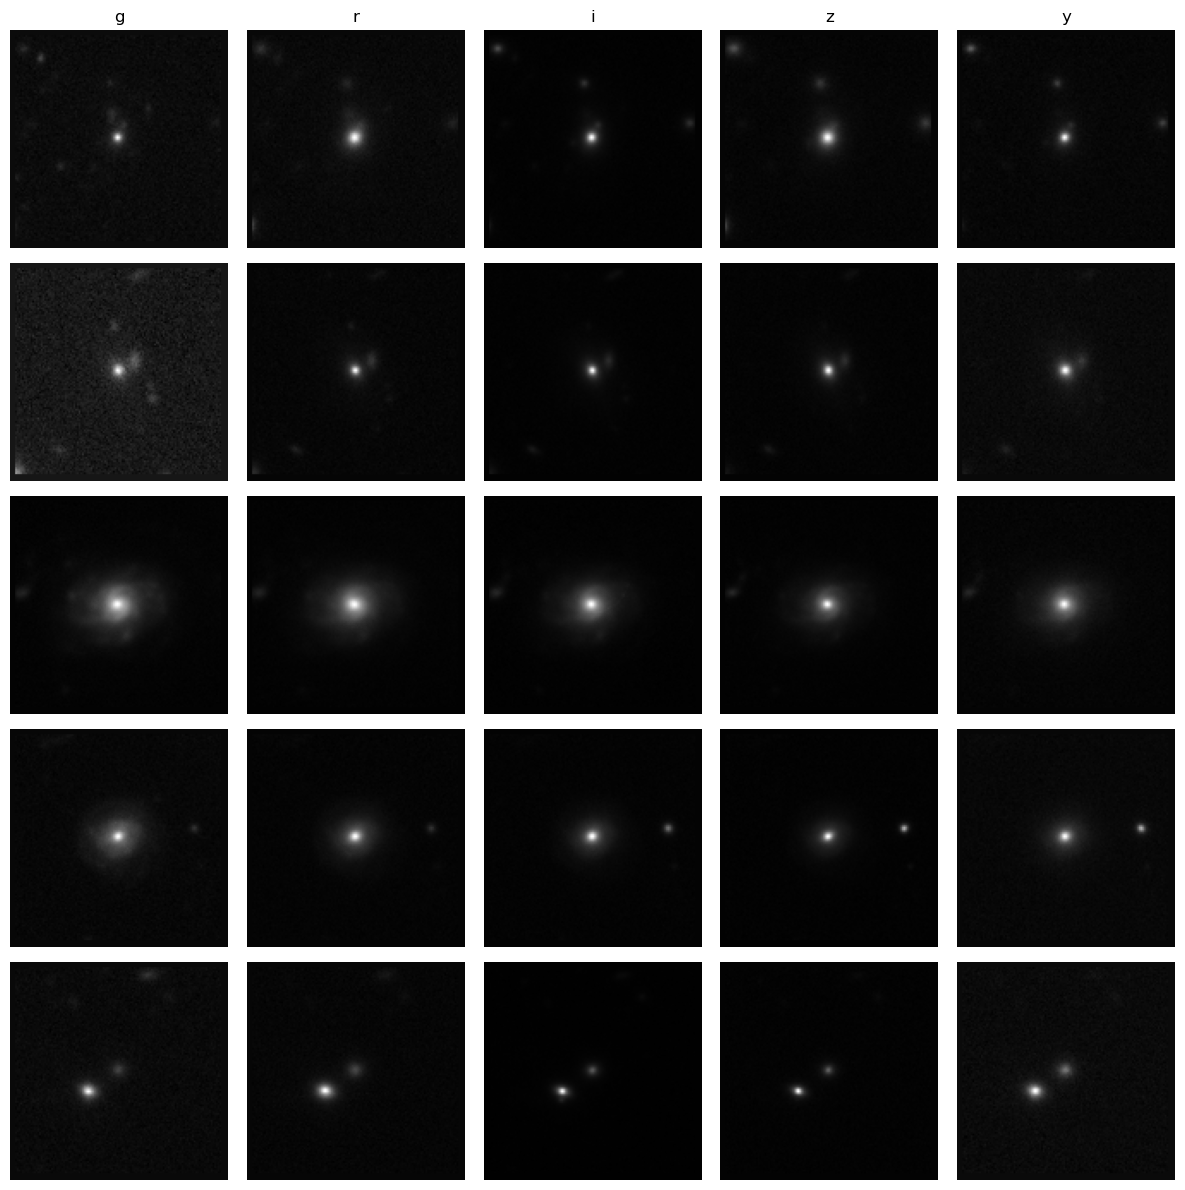

In [7]:
# Display five random galaxies across all five bands

bands = ["g", "r", "i", "z", "y"]

with h5py.File(validation_127_path, "r") as f:
    idx_val_127 = sorted(random.sample(range(len(df_val_127)), 5))
    images_val_127 = f["image"][idx_val_127]

fig, axes = plt.subplots(5, 5, figsize=(12, 12))

for row in range(5):
    for col in range(5):
        axes[row, col].imshow(images_val_127[row, col], cmap="gray")
        axes[row, col].axis("off")

        if row == 0:
            axes[row, col].set_title(bands[col])

plt.tight_layout()
plt.show()

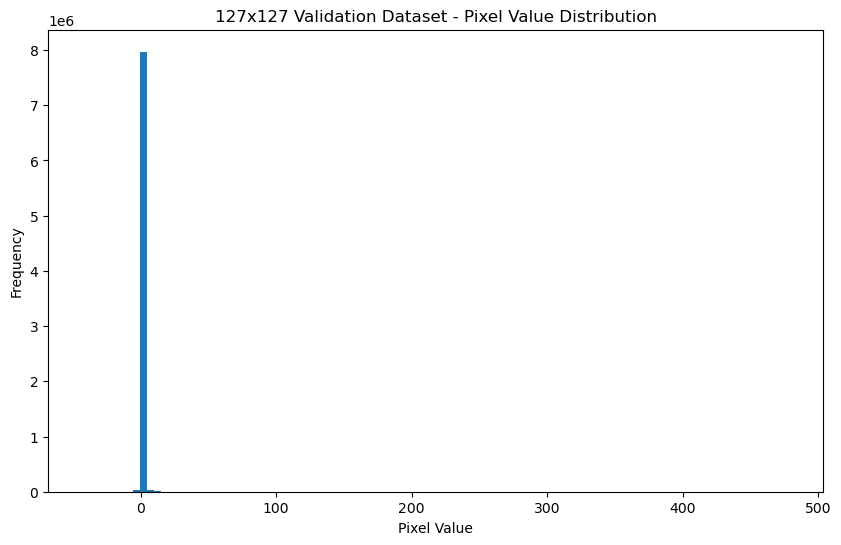

In [8]:
# Check the distribution of pixel values

with h5py.File(validation_127_path, "r") as f:
    sample_val_127 = f["image"][:100]

plt.figure(figsize=(10, 6))
plt.hist(sample_val_127.flatten(), bins=100)

plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.title("127x127 Validation Dataset - Pixel Value Distribution")
plt.show()

In [9]:
# Calculate mean, standard deviation, minimum and maximum for each galaxy

num_val_127 = len(df_val_127)

image_stats_val_127 = {
    band: {"mean": [], "std": [], "min": [], "max": []}
    for band in bands
}

with h5py.File(validation_127_path, "r") as f:
    images = f["image"]

    for start in range(0, num_val_127, 500):
        end = min(start + 500, num_val_127)
        batch = images[start:end]

        for i, band in enumerate(bands):
            band_data = batch[:, i, :, :]

            image_stats_val_127[band]["mean"].append(
                np.mean(band_data, axis=(1, 2))
            )
            
            image_stats_val_127[band]["std"].append(
                np.std(band_data, axis=(1, 2))
            )
            
            image_stats_val_127[band]["min"].append(
                np.min(band_data, axis=(1, 2))
            )
            
            image_stats_val_127[band]["max"].append(
                np.max(band_data, axis=(1, 2))
            )

# Combine batches
for band in bands:
    for stat in image_stats_val_127[band]:
        image_stats_val_127[band][stat] = np.concatenate(
            image_stats_val_127[band][stat]
        )

print("Image statistics calculated successfully.")

Image statistics calculated successfully.


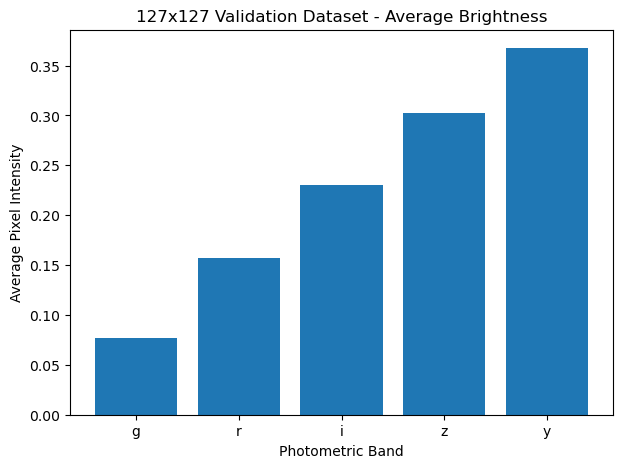

In [10]:
# Compare average brightness across photometric bands

mean_brightness_val_127 = [
    np.mean(image_stats_val_127[band]["mean"])
    for band in bands
]

plt.figure(figsize=(7, 5))
plt.bar(bands, mean_brightness_val_127)

plt.xlabel("Photometric Band")
plt.ylabel("Average Pixel Intensity")
plt.title("127x127 Validation Dataset - Average Brightness")
plt.show()

In [11]:
# Calculate the mean image for each photometric band

mean_band_val_127 = np.zeros((5, 127, 127), dtype=np.float64)

with h5py.File(validation_127_path, "r") as f:
    images = f["image"]

    for start in range(0, num_val_127, 500):
        end = min(start + 500, num_val_127)
        batch = images[start:end]

        mean_band_val_127 += batch.sum(axis=0)

mean_band_val_127 /= num_val_127

print("Mean image shape:", mean_band_val_127.shape)

Mean image shape: (5, 127, 127)


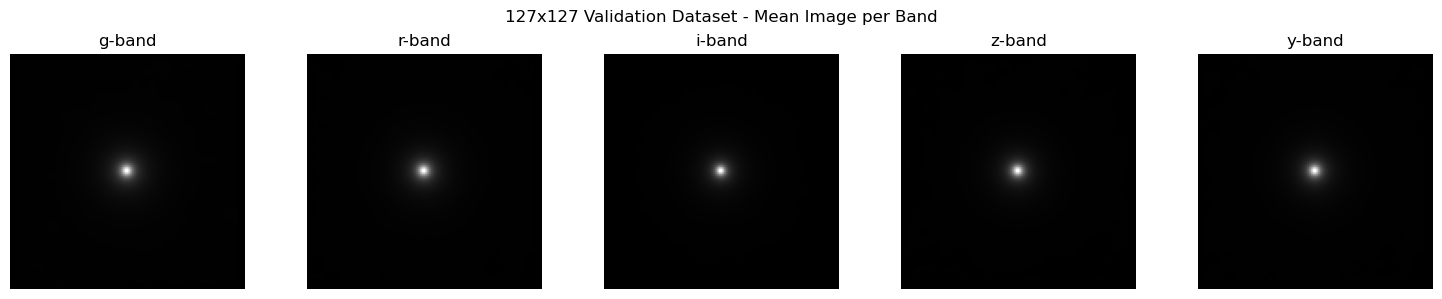

In [12]:
# Display the average image for each band

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, band in enumerate(bands):
    axes[i].imshow(mean_band_val_127[i], cmap="gray")
    axes[i].set_title(f"{band}-band")
    axes[i].axis("off")

plt.suptitle("127x127 Validation Dataset - Mean Image per Band")
plt.tight_layout()
plt.show()

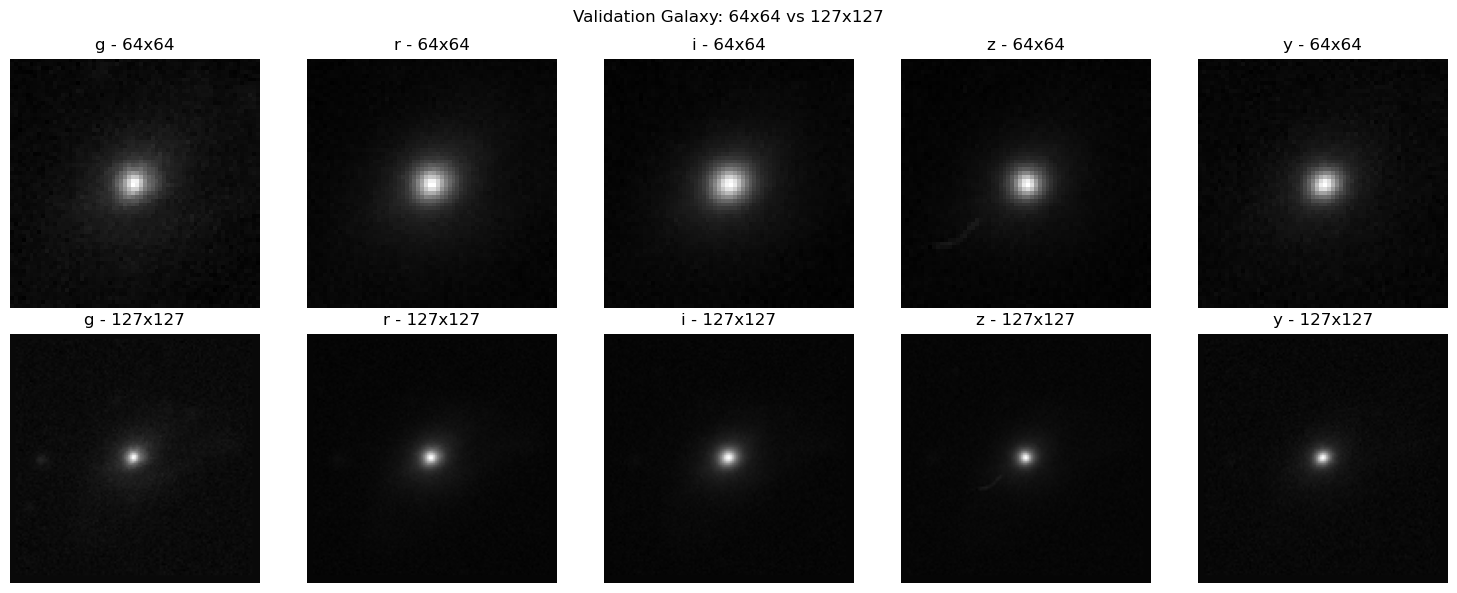

In [14]:
# Compare the same validation galaxy at 64x64 and 127x127 resolution

galaxy_index = 0

with h5py.File(validation_path, "r") as f:
    galaxy_64_val = f["image"][galaxy_index]

with h5py.File(validation_127_path, "r") as f:
    galaxy_127_val = f["image"][galaxy_index]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, band in enumerate(bands):
    axes[0, i].imshow(galaxy_64_val[i], cmap="gray")
    axes[0, i].set_title(f"{band} - 64x64")
    axes[0, i].axis("off")

    axes[1, i].imshow(galaxy_127_val[i], cmap="gray")
    axes[1, i].set_title(f"{band} - 127x127")
    axes[1, i].axis("off")

plt.suptitle("Validation Galaxy: 64x64 vs 127x127")
plt.tight_layout()
plt.show()

In [15]:
# Check for invalid pixel values in the 127x127 validation images

nan_count = 0
inf_count = 0

with h5py.File(validation_127_path, "r") as f:
    images = f["image"]

    for start in range(0, num_val_127, 500):
        end = min(start + 500, num_val_127)
        batch = images[start:end]

        nan_count += np.isnan(batch).sum()
        inf_count += np.isinf(batch).sum()

print("NaN pixel values:", nan_count)
print("Infinite pixel values:", inf_count)

NaN pixel values: 0
Infinite pixel values: 0


In [16]:
# Check for galaxies with almost no detectable pixel signal

near_blank = 0
threshold = 1e-6

with h5py.File(validation_127_path, "r") as f:
    images = f["image"]

    for start in range(0, num_val_127, 500):
        end = min(start + 500, num_val_127)
        batch = images[start:end]

        image_signal = np.max(np.abs(batch), axis=(1, 2, 3))
        near_blank += np.sum(image_signal < threshold)

print("Near-blank galaxies:", near_blank)

Near-blank galaxies: 0


In [17]:
# Find the overall minimum and maximum pixel values

overall_min = np.inf
overall_max = -np.inf

with h5py.File(validation_127_path, "r") as f:
    images = f["image"]

    for start in range(0, num_val_127, 500):
        end = min(start + 500, num_val_127)
        batch = images[start:end]

        overall_min = min(overall_min, np.min(batch))
        overall_max = max(overall_max, np.max(batch))

print("Minimum pixel value:", overall_min)
print("Maximum pixel value:", overall_max)

Minimum pixel value: -633.2002
Maximum pixel value: 1928.2434


In [18]:
# Final summary of the 127x127 validation dataset

print("===== 127x127 VALIDATION EDA SUMMARY =====")
print("Number of galaxies:", num_val_127)
print("Image shape:", (5, 127, 127))
print("Missing metadata values:", df_val_127.isnull().sum().sum())
print("Duplicate metadata rows:", df_val_127.duplicated().sum())
print("NaN pixels:", nan_count)
print("Infinite pixels:", inf_count)
print("Near-blank galaxies:", near_blank)
print("Minimum pixel value:", overall_min)
print("Maximum pixel value:", overall_max)

===== 127x127 VALIDATION EDA SUMMARY =====
Number of galaxies: 40914
Image shape: (5, 127, 127)
Missing metadata values: 0
Duplicate metadata rows: 0
NaN pixels: 0
Infinite pixels: 0
Near-blank galaxies: 0
Minimum pixel value: -633.2002
Maximum pixel value: 1928.2434
